In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
path=r"C:\Users\chenq\My Work\吴恩达机器学习作业\ex2data1.txt"
data = pd.read_csv(path,header=None,names=['Exam 1','Exam 2','Admitted'])
data.head()

,Exam 1,Exam 2,Admitted
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


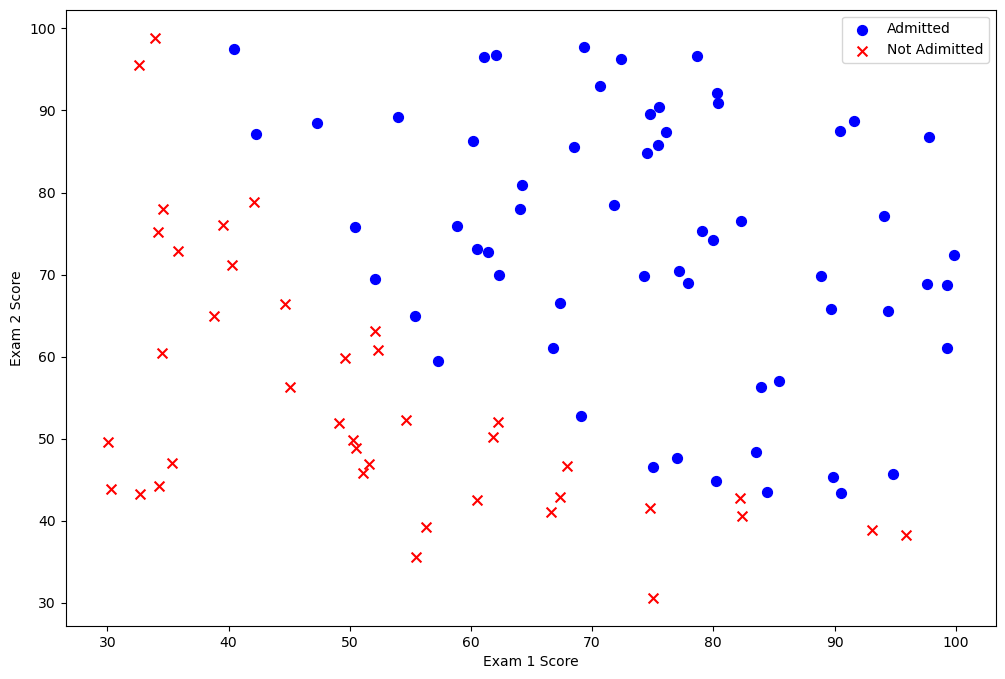

In [3]:
positive = data[data['Admitted'].isin([1])]
negative = data[data['Admitted'].isin([0])]

fig,ax=plt.subplots(figsize=(12,8))
ax.scatter(positive['Exam 1'],positive['Exam 2'],s=50,c='b',marker='o',label='Admitted')
ax.scatter(negative['Exam 1'],negative['Exam 2'],s=50,c='r',marker='x',label='Not Adimitted')
ax.legend()
ax.set_xlabel('Exam 1 Score')
ax.set_ylabel('Exam 2 Score')
plt.show()

In [4]:
def sigmoid(z):
    return 1/(1+np.exp(-z))
def cost(theta,X,y):
    theta = np.matrix(theta)
    X = np.matrix(X)
    y = np.matrix(y)
    first = np.multiply(-y,np.log(sigmoid(X*theta.T)))
    second=np.multiply((1-y),np.log(1-sigmoid(X*theta.T)))
    return np.sum(first-second)/(len(X))

In [5]:
data.insert(0,'Ones',1)
cols=data.shape[1]
X=data.iloc[:,0:cols-1]
y=data.iloc[:,cols-1:cols]
theta = np.zeros(3)

X = np.array(X.values)
y = np.array(y.values)

In [6]:
print(X.shape,theta.shape,y.shape)

(100, 3) (3,) (100, 1)


In [7]:
cost(theta,X,y)

np.float64(0.6931471805599453)

In [8]:
def gradient(theta,X,y):
    theta = np.matrix(theta)
    X = np.matrix(X)
    y = np.matrix(y)

    parameters = int(theta.ravel().shape[1])
    grad = np.zeros(parameters)

    error = sigmoid(X*theta.T)-y

    for i in range(parameters):
        term = np.multiply(error,X[:,i])
        grad[i] = np.sum(term) / len(X)

    return grad
    

In [10]:
import scipy.optimize as opt
result = opt.fmin_tnc(func=cost,x0=theta,fprime=gradient,args=(X,y))
result

(array([-25.16131863,   0.20623159,   0.20147149]), 36, 0)

In [11]:
cost(result[0],X,y)

np.float64(0.20349770158947458)

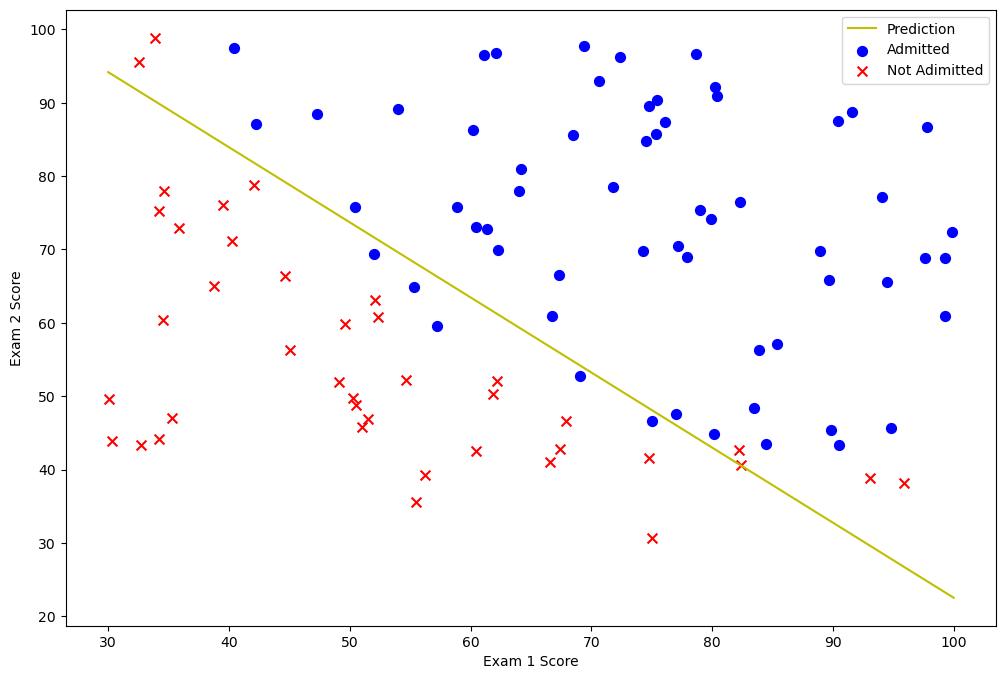

In [13]:
plotting_x1 = np.linspace(30,100,100)
plotting_h1 = (- result[0][0] - result[0][1] *plotting_x1)/result[0][2]

fig, ax =plt.subplots(figsize=(12,8))
ax.plot(plotting_x1,plotting_h1,'y',label='Prediction')
ax.scatter(positive['Exam 1'],positive['Exam 2'],s=50,c='b',marker='o',label='Admitted')
ax.scatter(negative['Exam 1'],negative['Exam 2'],s=50,c='r',marker='x',label='Not Adimitted')
ax.legend()
ax.set_xlabel("Exam 1 Score")
ax.set_ylabel("Exam 2 Score")
plt.show()

In [16]:
def hfunc1(theta,X):
    return sigmoid(np.dot(theta.T,X))
hfunc1(result[0],[1,45,85])

np.float64(0.7762906240463825)

In [17]:
def predict(theta,X):
    probability =sigmoid(X*theta.T)
    return [1 if x>=0.5 else 0 for x in probability]

In [18]:
theta_min = np.matrix(result[0])
predictions = predict(theta_min,X)
correct = [1 if ((a == 1 and b == 1) or (a == 0 and b==0)) else 0 for(a,b) in zip(predictions,y)]
accuracy = (sum(map(int,correct))%len(correct))
print('accuracy = {0}%'.format(accuracy))

accuracy = 89%
